In [ ]:
!pip install windpowerlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 3.0 MB/s eta 0:00:00


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from windpowerlib import data as wt
from windpowerlib import TurbineClusterModelChain, WindTurbine, WindFarm, ModelChain

In [19]:
Weather_Data = pd.read_csv('weather-montreal.csv', index_col=0, header=[0,1],date_parser = lambda idx: pd.to_datetime(idx, utc = True) ) #date_parser = lambda idx: pd.to_datetime(idx, utc = True)
Weather_Data

/tmp/ipykernel_7692/3992205716.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  Weather_Data = pd.read_csv('weather-montreal.csv', index_col=0, header=[0,1],date_parser = lambda idx: pd.to_datetime(idx, utc = True) ) #date_parser = lambda idx: pd.to_datetime(idx, utc = True)


variable_name,pressure,temperature,wind_speed,roughness_length,temperature,wind_speed
height,0,2,10,0,10,50
2019-01-01 00:00:00+00:00,99760,273.37,7.11,0.15,273.27,9.85
2019-01-01 01:00:00+00:00,99480,273.56,6.87,0.15,273.46,10.08
2019-01-01 02:00:00+00:00,99200,273.58,6.21,0.15,273.48,9.27
2019-01-01 03:00:00+00:00,98910,273.61,3.66,0.15,273.51,6.51
2019-01-01 04:00:00+00:00,98760,273.58,1.26,0.15,273.48,2.28
...,...,...,...,...,...,...
2019-12-31 19:00:00+00:00,99430,271.17,2.39,0.15,271.07,3.93
2019-12-31 20:00:00+00:00,99400,271.35,2.59,0.15,271.25,4.69
2019-12-31 21:00:00+00:00,99370,271.69,3.28,0.15,271.59,6.39


In [20]:
Selected_Turbine = {'turbine_type':'E48/800', 'hub_height':60}
W_Turbine = WindTurbine(**Selected_Turbine)

In [21]:
#wind_turbine_fleet = pd.DataFrame({'wind_turbine':[W_Turbine,None], 'number_of_turbines':[10,None]})

In [22]:
farm_data = {
    'wind_turbine_fleet':[W_Turbine.to_group(10)],
    'efficiency':0.9
}
farm_data_1 = WindFarm(**farm_data)
Wind_Farm_Submodel = {
    'wake_losses_model':'wind_farm_efficiency',
    'smoothing':True,
    'standard_deviation_method':'turbulence_intensity',
    'wind_speed_model':'hellman',
    'density_model':'ideal_gas',
    'temperature_model':'linear_gradient',
    'power_output_model': 'power_curve',
    'density_correction':True,
    'obstacle_height':0,
    'hellman_exp':0.25
}

Model_Farm = TurbineClusterModelChain(farm_data_1,**Wind_Farm_Submodel).run_model(Weather_Data)
Farm_Power_Output = (Model_Farm.power_output)/1000
Farm_Power_Output

,feedin_power_plant
2019-01-01 00:00:00+00:00,5143.800555
2019-01-01 01:00:00+00:00,5336.078841
2019-01-01 02:00:00+00:00,4558.117848
2019-01-01 03:00:00+00:00,1690.422179
2019-01-01 04:00:00+00:00,30.979601
...,...
2019-12-31 19:00:00+00:00,317.855421
2019-12-31 20:00:00+00:00,586.182770
2019-12-31 21:00:00+00:00,1620.965002
2019-12-31 22:00:00+00:00,2868.697185


In [23]:
Wind_Sub_Model = {
    'wind_speed_model':'hellman',
    'density_model':'ideal_gas',
    'temperature_model':'linear_gradient',
    'power_output_model':'power_coefficient_curve',
    'density_correction':True,
    'obstacle_height':0,
    'hellman_exp':.25
}

Model = ModelChain(W_Turbine,**Wind_Sub_Model).run_model(Weather_Data)

Turbine_Power_Output = (Model.power_output)/1000
Turbine_Power_Output

,feedin_power_plant
2019-01-01 00:00:00+00:00,607.007263
2019-01-01 01:00:00+00:00,632.135315
2019-01-01 02:00:00+00:00,518.769474
2019-01-01 03:00:00+00:00,167.707041
2019-01-01 04:00:00+00:00,1.009322
...,...
2019-12-31 19:00:00+00:00,28.706123
2019-12-31 20:00:00+00:00,57.379249
2019-12-31 21:00:00+00:00,160.043377
2019-12-31 22:00:00+00:00,289.477526


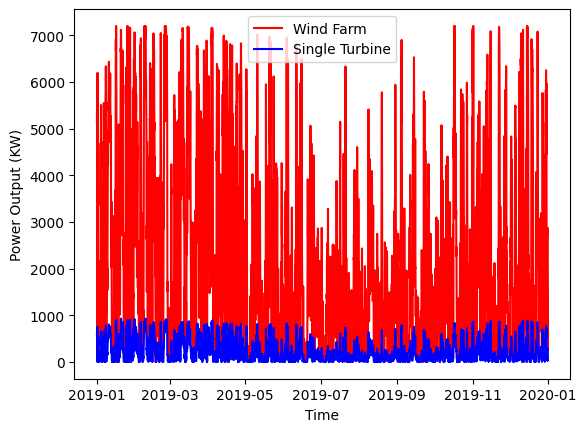

In [24]:
plt.plot(Farm_Power_Output, label='Wind Farm',c='r')
plt.plot(Turbine_Power_Output, label='Single Turbine',c='b')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Power Output (KW)')
plt.show()